# Tutorial 4: Unsupervised Learning with TabCamel

This tutorial demonstrates how to perform unsupervised learning tasks using TabCamel, including data preprocessing, PCA dimensionality reduction, and K-means clustering with visualization.

## Overview

In this tutorial, we will:
- Load a dataset for unsupervised learning
- Preprocess and transform the data
- Apply PCA for dimensionality reduction
- Perform K-means clustering
- Visualize the clustering results

## 1. Setup and Configuration

First, let's configure the Jupyter notebook environment with auto-reloading and inline plotting.

In [1]:
# Enable auto-reloading of modules when they change
%load_ext autoreload
%autoreload 2

# Configure matplotlib to display plots inline
%matplotlib inline

## 2. Load Dataset for Unsupervised Learning

We'll use the mfeat-fourier dataset, which contains Fourier coefficients of character shapes. This dataset is well-suited for clustering tasks.

In [2]:
# Import the main TabularDataset class
from tabcamel.data.dataset import TabularDataset

In [3]:
# Load the dataset for unsupervised learning
dataset = TabularDataset(
    dataset_name="mfeat-fourier",
    task_type="unsupervision",
)

dataset

TabularDataset(dataset_name=mfeat-fourier, task_type=unsupervision, target_col=None, is_tensor=False)

## 3. Dataset Overview and Exploration

Let's examine the structure and basic information about our dataset.

In [4]:
# Display dataset summary information
print(dataset)

============================DATA INFO============================
Dataset: mfeat-fourier
Task type: unsupervision
Status (is_tensor): False
Number of samples: 2000
Number of features: 77 (Numerical: 76, Categorical: 1)
Number of classes: None
Class distribution: None


In [5]:
# Explore the first few rows of the dataset
dataset.data_df.head()

,att1,att2,att3,att4,att5,att6,att7,att8,att9,att10,...,att68,att69,att70,att71,att72,att73,att74,att75,att76,class
0,0.065882,0.197312,0.103826,0.270362,0.616078,0.035856,0.424572,0.089701,0.367773,0.037065,...,0.113374,0.074343,0.281666,0.067795,0.344182,0.038963,0.394366,0.049971,0.344871,1
1,0.049142,0.175971,0.105515,0.227095,0.599280,0.041217,0.431078,0.096801,0.326739,0.059661,...,0.069337,0.045386,0.254264,0.045447,0.335659,0.021719,0.445277,0.083978,0.354092,1
2,0.034172,0.227649,0.108766,0.127697,0.612494,0.056554,0.470639,0.041903,0.324267,0.044569,...,0.218842,0.041087,0.360464,0.047154,0.377408,0.052099,0.445029,0.071234,0.261465,1
3,0.062336,0.217979,0.080243,0.289592,0.546316,0.045779,0.425545,0.022841,0.331454,0.119052,...,0.085479,0.087658,0.151880,0.075950,0.293462,0.022675,0.408291,0.063010,0.401376,1
4,0.061970,0.198358,0.111239,0.253460,0.608455,0.023631,0.415246,0.091866,0.309310,0.049142,...,0.106960,0.032283,0.248565,0.015674,0.386276,0.039481,0.434701,0.069218,0.405403,1


## 4. Data Splitting

Split the dataset into training and test sets using a random split with an 80/20 ratio.

In [6]:
# Split the dataset into train and test sets
split_dict = dataset.split(
    test_size=0.2,
    split_mode="random",
)

train_set = split_dict["train_set"]
test_set = split_dict["test_set"]

print(f"Training set size: {len(train_set.data_df)}")
print(f"Test set size: {len(test_set.data_df)}")

Training set size: 1600
Test set size: 400


## 5. Data Preprocessing and Transformation

Apply standard scaling to normalize the numerical features, which is important for clustering algorithms like K-means that are sensitive to feature scales.

In [7]:
from tabcamel.data.transform import NumericTransform

# Create and apply numeric transformation
transform = NumericTransform(
    numerical_feature_list=train_set.numerical_feature_list,
    strategy="standard",  # Standard scaling (z-score normalization)
    include_categorical=False,
)

# Fit the transformer on training data and transform both sets
train_data = train_set.data_df
transform.fit(train_data)
train_data_transformed = transform.transform(train_data)
test_data_transformed = transform.transform(test_set.data_df)

print(f"Original feature dimension: {train_data.shape[1]}")
print(f"Data type after transformation: {type(train_data_transformed)}")

Original feature dimension: 77
Data type after transformation: <class 'pandas.core.frame.DataFrame'>


## 6. Dimensionality Reduction with PCA

Use Principal Component Analysis (PCA) to reduce the data dimensionality to 2 components for visualization purposes.

In [8]:
from sklearn.decomposition import PCA

# Apply PCA to reduce dimensionality to 2 components for visualization
pca = PCA(n_components=2)
train_data_reduced = pca.fit_transform(train_data_transformed)
test_data_reduced = pca.transform(test_data_transformed)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.3f}")
print(f"Reduced data shape: {train_data_reduced.shape}")

Explained variance ratio: [0.16130328 0.08894868]
Total explained variance: 0.250
Reduced data shape: (1600, 2)


## 7. K-Means Clustering

Apply K-means clustering algorithm with 10 clusters on the PCA-reduced training data.

In [9]:
from sklearn.cluster import KMeans

# Apply K-means clustering
kmeans = KMeans(
    init="k-means++",  # Smart initialization
    n_clusters=10,     # Number of clusters (matches the number of digit classes)
    n_init=4,          # Number of random initializations
    random_state=42    # For reproducibility
)

# Fit the model on reduced training data
kmeans.fit(train_data_reduced)

print(f"Number of clusters: {kmeans.n_clusters}")
print(f"Cluster centers shape: {kmeans.cluster_centers_.shape}")
print(f"Inertia (within-cluster sum of squares): {kmeans.inertia_:.2f}")

Number of clusters: 10
Cluster centers shape: (10, 2)
Inertia (within-cluster sum of squares): 2329.16


## 8. Cluster Visualization Function

Define a function to visualize clustering results with decision boundaries, data points, and cluster centroids.

In [10]:
import matplotlib.pyplot as plt
import numpy as np


def visualise_clusters(reduced_data, model, title_suffix=""):
    """
    Visualize clustering results with decision boundaries and centroids.

    Parameters:
    -----------
    reduced_data : numpy.ndarray
        2D array of PCA-reduced data points
    model : sklearn.cluster.KMeans
        Fitted K-means model
    title_suffix : str
        Additional text to add to the plot title
    """
    # Step size of the mesh. Decrease to increase the quality of the visualization
    h = 0.02

    # Define the mesh boundaries
    x_min, x_max = reduced_data[:, 0].min() - 1, reduced_data[:, 0].max() + 1
    y_min, y_max = reduced_data[:, 1].min() - 1, reduced_data[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Obtain labels for each point in mesh using the trained model
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    # Create the color plot for decision boundaries
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(10, 8))
    plt.clf()
    plt.imshow(
        Z,
        interpolation="nearest",
        extent=(xx.min(), xx.max(), yy.min(), yy.max()),
        cmap=plt.cm.Paired,
        aspect="auto",
        origin="lower",
        alpha=0.8,
    )

    # Plot the data points
    plt.plot(reduced_data[:, 0], reduced_data[:, 1], "k.", markersize=2)

    # Plot the centroids as white X marks
    centroids = model.cluster_centers_
    plt.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker="x",
        s=169,
        linewidths=3,
        color="w",
        zorder=10,
    )

    plt.title(
        f"K-means clustering on the dataset (PCA-reduced data){title_suffix}\n" "Centroids are marked with white cross"
    )
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel("First Principal Component")
    plt.ylabel("Second Principal Component")
    plt.xticks(())
    plt.yticks(())
    plt.show()

## 9. Visualize Training Data Clusters

Apply the visualization function to display K-means clustering results on the training dataset.

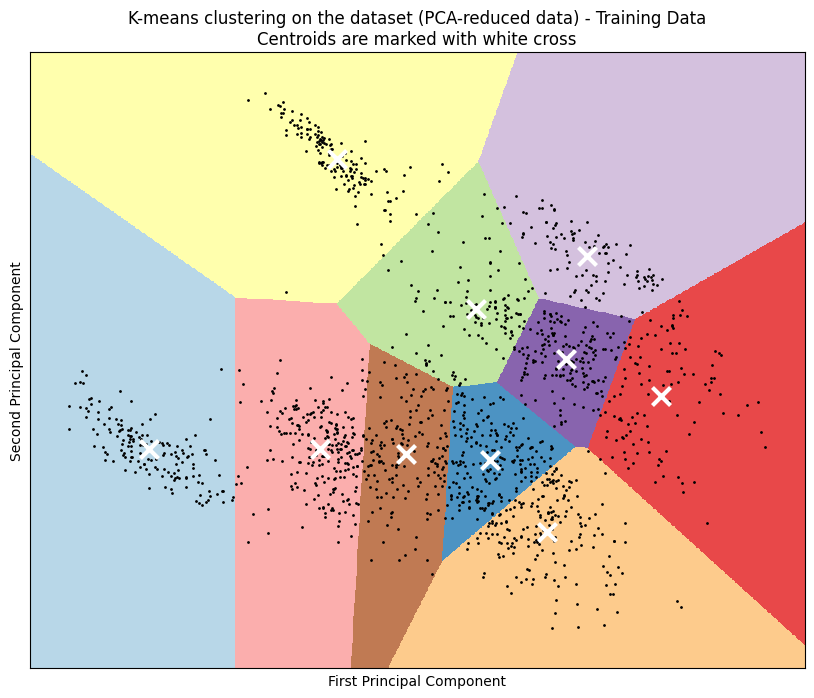

In [11]:
# Visualize clustering results on training data
visualise_clusters(train_data_reduced, kmeans, " - Training Data")

## 10. Visualize Test Data Clusters

Apply the visualization function to display K-means clustering results on the test dataset to see how the model generalizes.

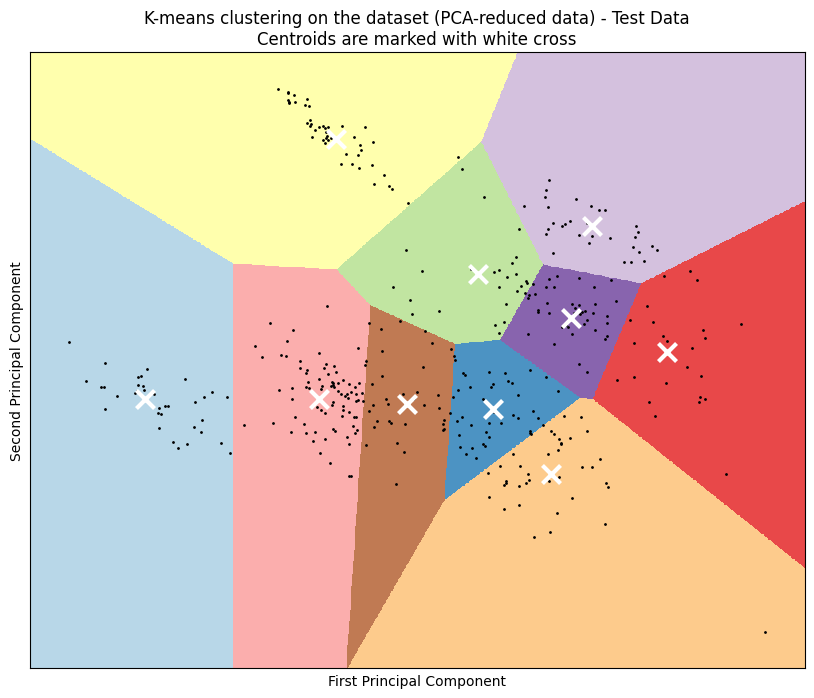

In [12]:
# Visualize clustering results on test data
visualise_clusters(test_data_reduced, kmeans, " - Test Data")

## Summary

In this tutorial, we have successfully:

1. **Loaded an unsupervised dataset** using TabCamel's `TabularDataset` class
2. **Explored the dataset structure** to understand our data
3. **Split the data** into training and test sets
4. **Preprocessed the data** using standard scaling normalization
5. **Applied PCA** to reduce dimensionality for visualization
6. **Performed K-means clustering** to identify patterns in the data
7. **Visualized the results** to understand the clustering structure

The visualizations show how the K-means algorithm partitions the data space and how well the clusters generalize from training to test data. The decision boundaries and cluster centroids provide insights into the underlying structure of the dataset.

### Key Takeaways

- **Data preprocessing** is crucial for clustering algorithms, especially normalization
- **PCA** helps visualize high-dimensional data and can improve clustering performance
- **K-means** is effective for identifying compact, spherical clusters
- **Visualization** is essential for understanding and validating clustering results

This workflow can be adapted for other unsupervised learning tasks and datasets available in TabCamel.